In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


In [2]:
# 1. Step up one level from wherever Jupyter is currently looking
search_area = os.path.dirname(os.getcwd())
csv_path = None

# 2. Scan all nearby folders for the file
for root, dirs, files in os.walk(search_area):
    for file in files:
        if file.lower() == 'steam.csv': # This checks for both 'steam' and 'Steam'
            csv_path = os.path.join(root, file)
            break
    if csv_path:
        break

# 3. Load the data if it finds it
if csv_path:
    df = pd.read_csv(csv_path)
   

In [3]:
df.head()

,title,rating,review
0,Can't access the games I paid for,1,I opened tickets HT-2FQ9-CY9F-355R and HT-VJ6D...
1,"Great Service, they deserve a monopoly.",5,This must be at least 10 characters.
2,There is no service,1,There is no service. There is no help. There i...
3,I used Steam for years gaming on a PC…,2,I used Steam for years gaming on a PC until th...
4,I was forced to download Steam to log…,1,I was forced to download Steam to log into S&b...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2374 entries, 0 to 2373
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   2374 non-null   str  
 1   rating  2374 non-null   int64
 2   review  2374 non-null   str  
dtypes: int64(1), str(2)
memory usage: 55.8 KB


In [5]:
df['rating'].value_counts()

rating
1    1626
5     443
4     117
2     113
3      75
Name: count, dtype: int64

In [6]:
df['rating_sentiment']=df['rating'].map({1:'negative',2:'negative',3:'neutral',4:'positive',5:'positive'})

In [7]:
df.head()

,title,rating,review,rating_sentiment
0,Can't access the games I paid for,1,I opened tickets HT-2FQ9-CY9F-355R and HT-VJ6D...,negative
1,"Great Service, they deserve a monopoly.",5,This must be at least 10 characters.,positive
2,There is no service,1,There is no service. There is no help. There i...,negative
3,I used Steam for years gaming on a PC…,2,I used Steam for years gaming on a PC until th...,negative
4,I was forced to download Steam to log…,1,I was forced to download Steam to log into S&b...,negative


In [8]:
df['rating_sentiment'].value_counts()

rating_sentiment
negative    1739
positive     560
neutral       75
Name: count, dtype: int64

# Machine Learning

In [9]:
vectorizer = TfidfVectorizer()

In [10]:
df['full_text'] = df['title'] + ". " + df['review']

In [11]:
X = vectorizer.fit_transform(df['full_text'])

In [12]:
y = df['rating_sentiment']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [14]:
model = RandomForestClassifier()

In [15]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
pred = model.predict(X_test)

In [17]:
accuracy_score(y_test, pred)

0.8315789473684211

In [18]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.82      0.99      0.90       343
     neutral       0.00      0.00      0.00        21
    positive       0.92      0.49      0.64       111

    accuracy                           0.83       475
   macro avg       0.58      0.49      0.51       475
weighted avg       0.81      0.83      0.80       475



c:\Users\aggel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aggel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aggel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# Plots

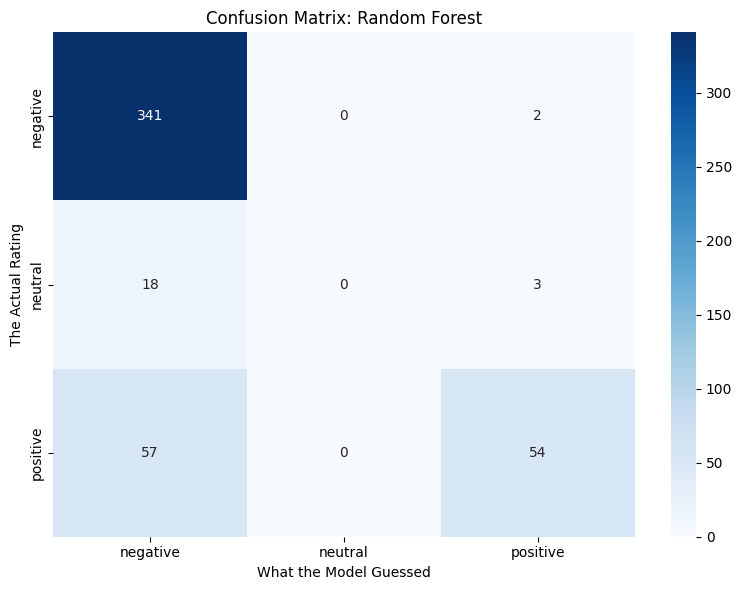

In [19]:
# Generate confusion matrix
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Rating')
plt.tight_layout()
plt.show()

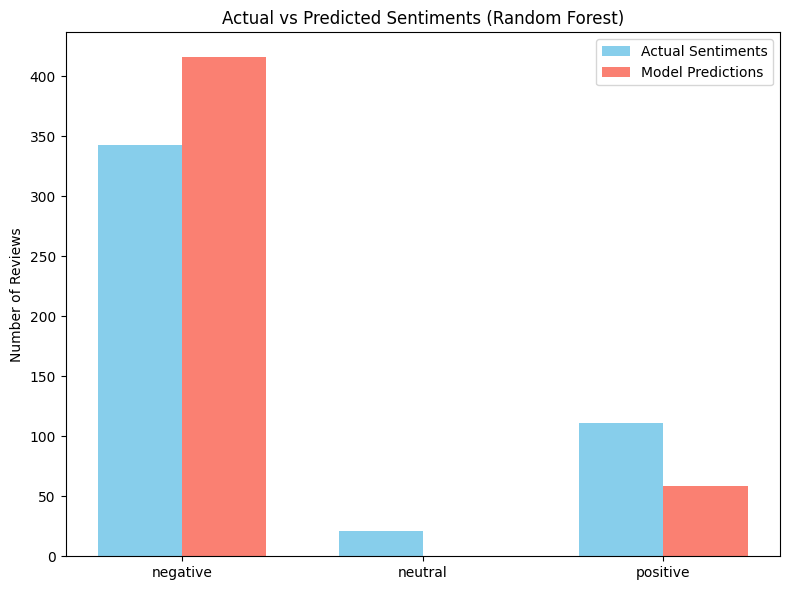

In [20]:
# Actual vs. Predicted Distribution
labels = ['negative', 'neutral', 'positive']

actual_counts = y_test.value_counts().reindex(labels, fill_value=0)
predicted_counts = pd.Series(pred).value_counts().reindex(labels, fill_value=0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, actual_counts, width, label='Actual Sentiments', color='skyblue')
ax.bar(x + width/2, predicted_counts, width, label='Model Predictions', color='salmon')

ax.set_ylabel('Number of Reviews')
ax.set_title('Actual vs Predicted Sentiments (Random Forest)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

# TextBlob vs RandomForestClassifier

In [ ]:
# The names of your two models
models = ['TextBlob (Rule-Based)', 'Random Forest (Machine Learning)']

# *** CHANGE THESE NUMBERS! ***
# Put your TextBlob accuracy first, and your Random Forest accuracy second.
# For example, if you got 45.5% and 80%, type [0.455, 0.800]
accuracy_scores = [0.455, 0.800] 

# Build the comparison plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracy_scores, color=['lightgray', 'mediumseagreen'])
plt.ylim(0, 1.0) # Set the y-axis from 0 to 100%
plt.ylabel('Accuracy Score')
plt.title('Performance Comparison: TextBlob vs. Random Forest')

# Add the exact percentages directly on top of the bars for easy reading
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()